In [ ]:
#1. Carga y limpieza de datos

## a. Importar un conjunto de datos de propiedades en venta
from google.colab import drive
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

# Montar y cargar
try:
    drive.mount('/content/drive')
    ruta = '/content/drive/My Drive/Colab Notebooks/viviendas_chile.csv'
    data = pd.read_csv(ruta, delimiter=',')
    print("\n✅ Datos cargados correctamente\n")
except Exception as e:
    print(f"\n❌ Error al cargar el archivo: {e}\n")

## b. Aplicar técnicas de limpieza de datos
print("Primeras filas del dataset:")
display(data.head())

print("\nResumen del DataFrame:")
data.info()

print("\nValores nulos por columna:")
print(data.isnull().sum())

print(f"\nDuplicados: {data.duplicated().sum()}")

# Filtrar solo departamentos
data = data[data["Tipo Propiedad"].str.lower() == "departamento"]

# === Preprocesamiento para EDA ===
data["Estacionamiento_bin"] = data["Estacionamiento"].map({"Si": 1, "Sí": 1, "No": 0})
data["Bodega_bin"] = data["Bodega"].map({"Si": 1, "Sí": 1, "No": 0})

Mounted at /content/drive

✅ Datos cargados correctamente

Primeras filas del dataset:


,ID,Región,Comuna,Tipo Propiedad,Precio,Metros Totales,Metros Útiles,Habitaciones,Baños,Estacionamiento,Bodega,Año Construcción
0,1,Coquimbo,La Serena,Terreno,182546501,142,112,3,2,Sí,No,1982
1,2,Araucanía,Temuco,Casa,185667421,30,23,2,2,Sí,No,2022
2,3,Coquimbo,La Serena,Departamento,387368371,287,274,5,2,Sí,Sí,2013
3,4,Valparaíso,Valparaíso,Departamento,465340305,219,214,1,3,Sí,Sí,1984
4,5,Los Lagos,Puerto Montt,Terreno,485416587,175,162,5,2,Sí,Sí,1989



Resumen del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   ID                10000 non-null  int64 
 1   Región            10000 non-null  object
 2   Comuna            10000 non-null  object
 3   Tipo Propiedad    10000 non-null  object
 4   Precio            10000 non-null  int64 
 5   Metros Totales    10000 non-null  int64 
 6   Metros Útiles     10000 non-null  int64 
 7   Habitaciones      10000 non-null  int64 
 8   Baños             10000 non-null  int64 
 9   Estacionamiento   10000 non-null  object
 10  Bodega            10000 non-null  object
 11  Año Construcción  10000 non-null  int64 
dtypes: int64(7), object(5)
memory usage: 937.6+ KB

Valores nulos por columna:
ID                  0
Región              0
Comuna              0
Tipo Propiedad      0
Precio              0
Metros Totales      0
Metros Útile


Métricas del Precio:
Media: $265,896,917
Mediana: $267,968,678
Desviación estándar: $135,683,454
P25: $149,501,128 | P75: $384,554,625


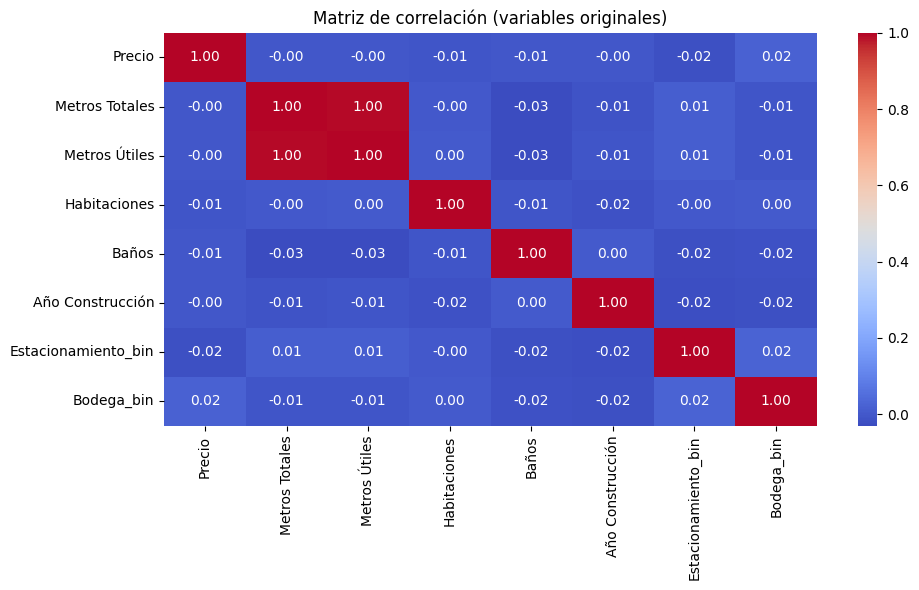

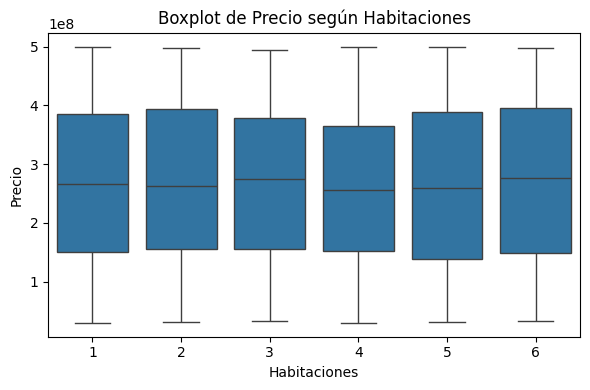

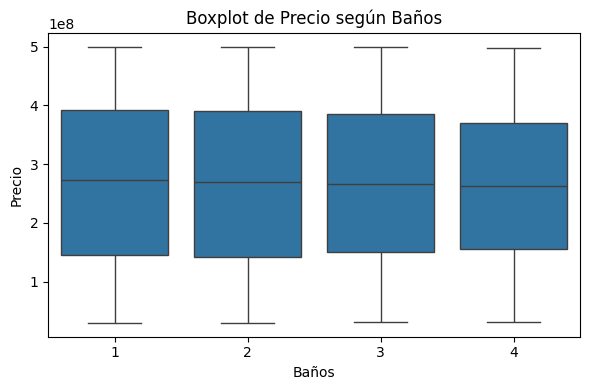

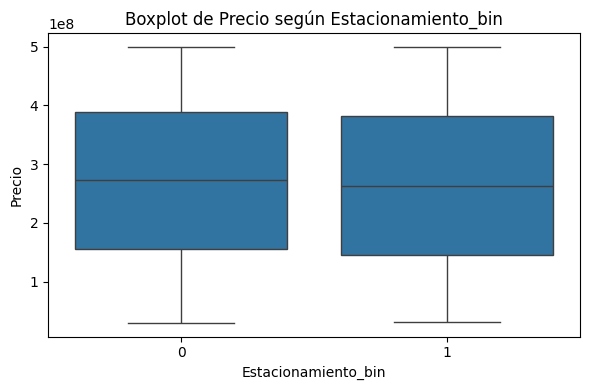

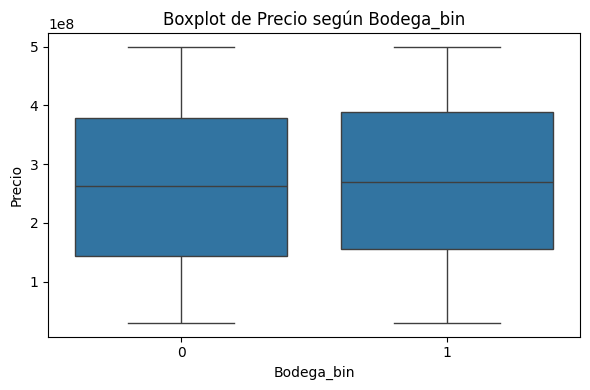

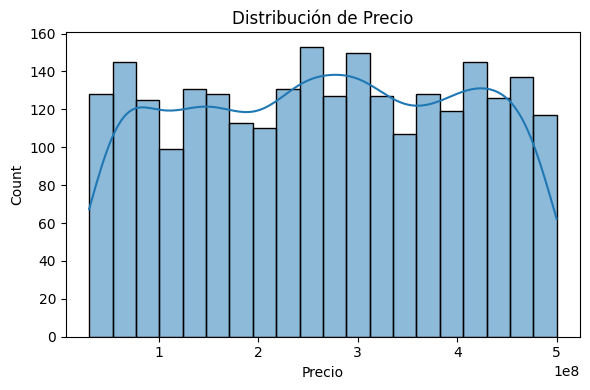

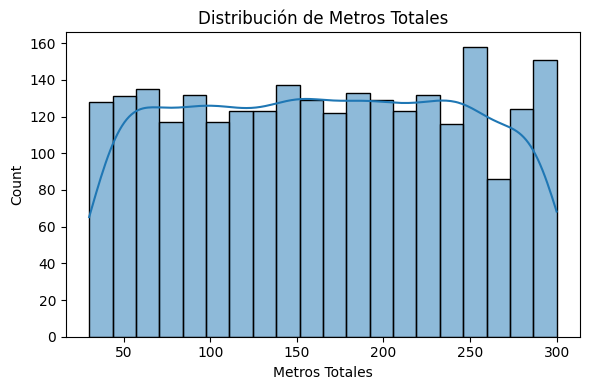

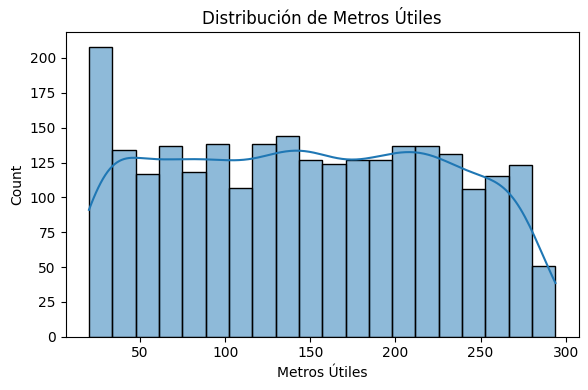

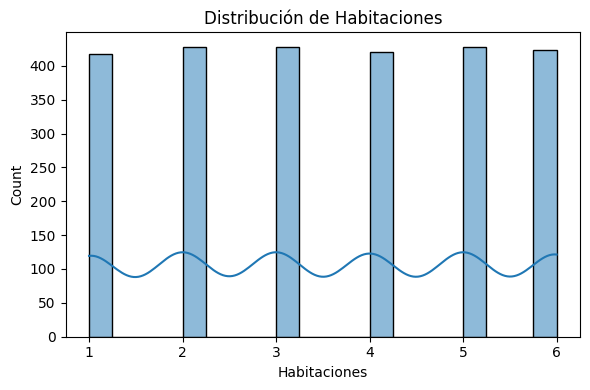

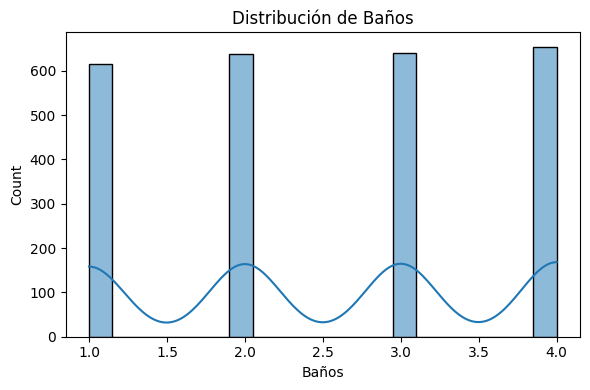

In [ ]:
#2. Análisis exploratorio de datos (EDA)

## a. Calcular métricas descriptivas
print("\nMétricas del Precio:")
precio = data["Precio"]
print(f"Media: ${precio.mean():,.0f}")
print(f"Mediana: ${precio.median():,.0f}")
print(f"Desviación estándar: ${precio.std():,.0f}")
print(f"P25: ${precio.quantile(0.25):,.0f} | P75: ${precio.quantile(0.75):,.0f}")

## b. Visualizaciones
# Matriz de correlación de variables originales
plt.figure(figsize=(10, 6))
corr_vars = ["Precio", "Metros Totales", "Metros Útiles", "Habitaciones", "Baños", "Año Construcción", "Estacionamiento_bin", "Bodega_bin"]
sns.heatmap(data[corr_vars].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación (variables originales)")
plt.tight_layout()
plt.show()

# Boxplots para variables categóricas y ordinales
for var in ["Habitaciones", "Baños", "Estacionamiento_bin", "Bodega_bin"]:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=data[var], y=data["Precio"])
    plt.title(f"Boxplot de Precio según {var}")
    plt.tight_layout()
    plt.show()

# Histogramas de variables numéricas
vars_hist = ["Precio", "Metros Totales", "Metros Útiles", "Habitaciones", "Baños"]
for var in vars_hist:
    plt.figure(figsize=(6, 4))
    sns.histplot(data[var], bins=20, kde=True)
    plt.title(f"Distribución de {var}")
    plt.tight_layout()
    plt.show()

## c. Limpieza y creación de nuevas variables
# Eliminar nulos en columnas clave
data = data.dropna(subset=["Precio", "Metros Útiles", "Año Construcción"])

# Convertir columnas necesarias
data["Estacionamiento"] = data["Estacionamiento"].map({"Si": 1, "Sí": 1, "No": 0})
data["Bodega"] = data["Bodega"].map({"Si": 1, "Sí": 1, "No": 0})
to_numeric = ["Precio", "Metros Totales", "Metros Útiles", "Habitaciones", "Baños", "Estacionamiento", "Bodega"]
for col in to_numeric:
    data[col] = pd.to_numeric(data[col], errors="coerce")

# Crear variables derivadas
data["Precio_m2"] = data["Precio"] / data["Metros Útiles"]

# Eliminar outliers
for col in ["Precio", "Metros Totales", "Metros Útiles", "Precio_m2"]:
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1
    data = data[(data[col] >= q1 - 1.5 * iqr) & (data[col] <= q3 + 1.5 * iqr)]

In [ ]:
#3. Aplicación de modelos predictivos

## a. Preparación del modelo
model_data = data.copy()
dummies = pd.get_dummies(model_data[["Región", "Comuna"]], drop_first=True)
X = pd.concat([model_data[["Metros Útiles", "Habitaciones", "Baños", "Precio_m2", "Estacionamiento", "Bodega"]], dummies], axis=1)
y = model_data["Precio"]

# División y escalado
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## b. Evaluación de modelos

def evaluar_modelos(Xtr, Xte, ytr, yte, etiqueta):
    resultados = []

    # Regresión Lineal
    lr = LinearRegression()
    lr.fit(Xtr, ytr)
    y_pred_lr = lr.predict(Xte)
    resultados.append({"Reducción": etiqueta, "Modelo": "Regresión Lineal", "R2": r2_score(yte, y_pred_lr), "MAE": mean_absolute_error(yte, y_pred_lr), "RMSE": np.sqrt(mean_squared_error(yte, y_pred_lr))})
    plt.figure(figsize=(6, 5))
    plt.scatter(yte, y_pred_lr, alpha=0.5)
    plt.plot([yte.min(), yte.max()], [yte.min(), yte.max()], 'r--')
    plt.title(f"Regresión Lineal ({etiqueta})")
    plt.xlabel("Precio Real")
    plt.ylabel("Precio Predicho")
    plt.tight_layout()
    plt.grid()
    plt.show()

    # KNN
    knn = KNeighborsRegressor(n_neighbors=5)
    knn.fit(Xtr, ytr)
    y_pred_knn = knn.predict(Xte)
    resultados.append({"Reducción": etiqueta, "Modelo": "KNN", "R2": r2_score(yte, y_pred_knn), "MAE": mean_absolute_error(yte, y_pred_knn), "RMSE": np.sqrt(mean_squared_error(yte, y_pred_knn))})
    plt.figure(figsize=(6, 5))
    plt.scatter(yte, y_pred_knn, alpha=0.5)
    plt.plot([yte.min(), yte.max()], [yte.min(), yte.max()], 'r--')
    plt.title(f"KNN Regressor ({etiqueta})")
    plt.xlabel("Precio Real")
    plt.ylabel("Precio Predicho")
    plt.tight_layout()
    plt.grid()
    plt.show()

    return resultados

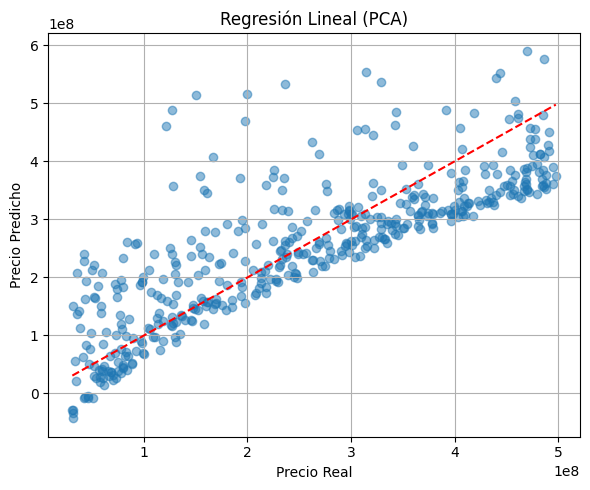

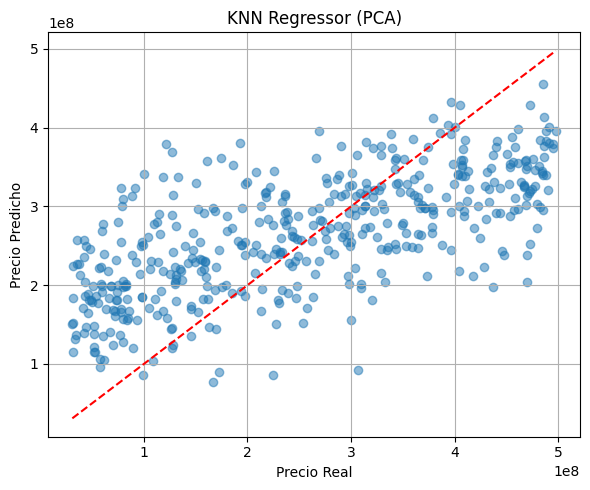

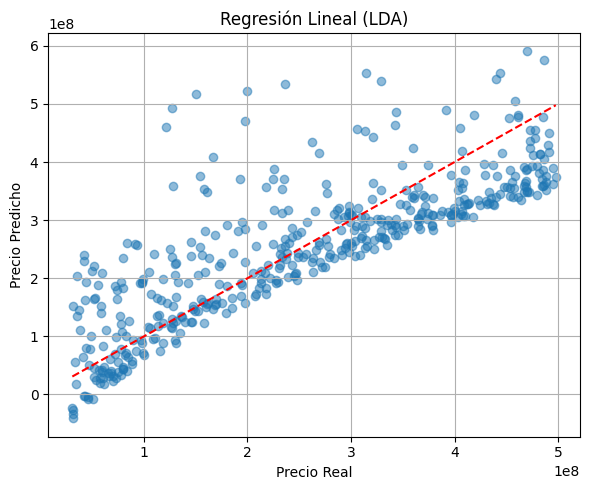

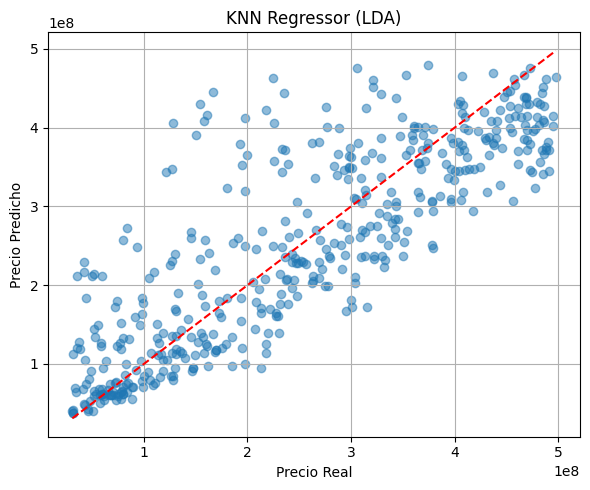

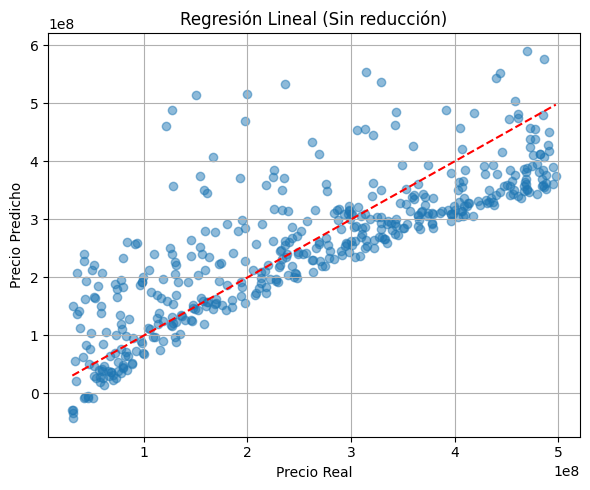

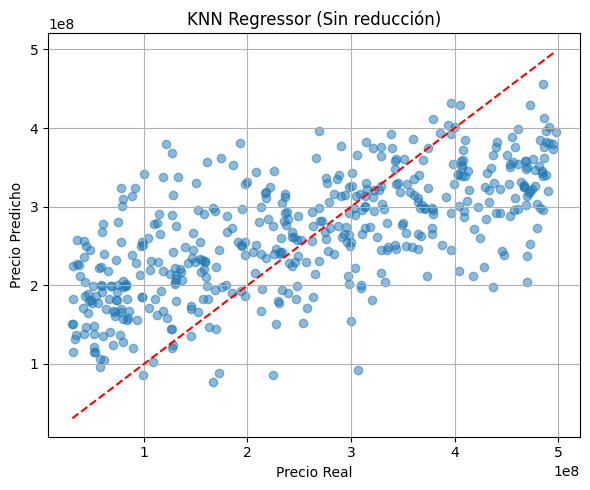


📊 Comparación de modelos:


,Reducción,Modelo,R2,MAE,RMSE
0,Sin reducción,Regresión Lineal,0.646,6.337825e+07,8.400232e+07
1,Sin reducción,KNN,0.427,8.885585e+07,1.067894e+08
2,PCA,Regresión Lineal,0.646,6.337825e+07,8.400232e+07
3,PCA,KNN,0.427,8.885585e+07,1.067894e+08
4,LDA,Regresión Lineal,0.645,6.323524e+07,8.403352e+07
5,LDA,KNN,0.691,5.907410e+07,7.842444e+07


In [ ]:
#4. Reducción de dimensionalidad y selección de atributos

## a. PCA
pca = PCA(n_components=0.99)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
res_pca = evaluar_modelos(X_train_pca, X_test_pca, y_train, y_test, "PCA")

## b. LDA
y_clas = pd.cut(y, bins=np.arange(0, 520_000_000, 50_000_000), labels=False)
lda = LDA(n_components=2)
X_train_lda = lda.fit_transform(X_train_scaled, y_clas[y_train.index])
X_test_lda = lda.transform(X_test_scaled)
res_lda = evaluar_modelos(X_train_lda, X_test_lda, y_train, y_test, "LDA")

# c. Comparación de modelos (sin reducción)
res_sin_red = evaluar_modelos(X_train_scaled, X_test_scaled, y_train, y_test, "Sin reducción")

# Resultados finales
resultados = pd.DataFrame(res_sin_red + res_pca + res_lda).round(3)
print("\n📊 Comparación de modelos:")
display(resultados)